<font size = "5"> **Chapter 4: [Spectroscopy](CH4_00-Spectroscopy.ipynb)** </font>

<hr style="height:1px;border-top:4px solid #FF8200" />

# Analyze EDS Spectrum

[Download](https://raw.githubusercontent.com/gduscher/MSE672-Introduction-to-TEM/main/Spectroscopy/CH4_16-Analyse_EDS.ipynb)
 

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
    https://colab.research.google.com/github/gduscher/MSE672-Introduction-to-TEM/blob/main//Spectroscopy/CH4_16-Analyse_EDS.ipynb)

part of 

<font size = "5"> **[MSE672:  Introduction to Transmission Electron Microscopy](../_MSE672_Intro_TEM.ipynb)**</font>

**Spring 2026**<br>
by Gerd Duscher

Microscopy Facilities<br>
Institute of Advanced Materials & Manufacturing<br>
Materials Science & Engineering<br>
The University of Tennessee, Knoxville

Background and methods to analysis and quantification of data acquired with transmission electron microscopes.


## Load relevant python packages
### Check Installed Packages

In [1]:
import sys
import importlib.metadata
def test_package(package_name):
    """Test if package exists and returns version or -1"""
    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = '-1'
    return version

if test_package('pyTEMlib') < '0.2026.1.1':
    print('installing pyTEMlib')
    !{sys.executable} -m pip install  --upgrade pyTEMlib -q

print('done')

done


## First we import the essential libraries
All we need here should come with the annaconda or any other package

The xml library will enable us to read the Bruker file.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
if 'google.colab' in sys.modules:
    from google.colab import output
    from google.colab import drive
    output.enable_custom_widget_manager()
    
import pyTEMlib

# For archiving reasons it is a good idea to print the version numbers out at this point
print('pyTEM version: ',pyTEMlib.__version__)

pyTEM version:  0.2026.1.3


## Select File

Please note that the above code cell has to be finished before you can open the * open file* dialog.

Test data are in the **SEM_example_data** folder, plese select EDS.rto file.

In [2]:
if 'google.colab' in sys.modules:
    if not os.path.exists('./EDS.rto'):
        !wget  https://github.com/gduscher/MSE672-Introduction-to-TEM/raw/main/example_data/EDS.rto'
        !wget  https://github.com/gduscher/MSE672-Introduction-to-TEM/raw/main/example_data/1EELS Acquire (low-loss).dm3
    example_path = "."
else:
    example_path = os.path.join(os.path.abspath(""), "../example_data")

# file_widget = pyTEMlib.file_tools.FileWidget(dir_name=example_path)

### Function to read Bruker files
The data and metadata will be in a python dictionary called tags.

In [3]:
import xml
import codecs

def get_bruker_dictionary(fname):
    tree =  xml.etree.ElementTree.parse(fname)
    root = tree.getroot()
    spectrum_number = 0
    i=0
    image_count = 0
    o_count = 0
    tags = {}
    for neighbor in root.iter():
        #print(neighbor, neighbor.attrib)
        
        if 'Type' in neighbor.attrib:
            if 'verlay3' in neighbor.attrib['Type'] :
                semImage = neighbor
                #print(neighbor.attrib['Type'])
                if 'Name' in neighbor.attrib:
                    print('\t',neighbor)
                    print('\t',neighbor.attrib['Type'])
                    print('\t',neighbor.attrib['Name'])
                    print('\t',neighbor.find("./ClassInstance[@Type='TRTSpectrumList']"))
            #if 'TRTImageOverlay' in neighbor.attrib['Type'] : 
            if 'TRTCrossOverlayElement'in neighbor.attrib['Type'] :
                if 'Spectrum' in neighbor.attrib['Name']:
                    #print(o_count)
                    o_count+=1
                    if 'overlay' not in tags:
                        tags['overlay']= {}
                    if 'image'+str(image_count) not in tags['overlay']:
                        tags['overlay']['image'+str(image_count)] ={}
                    tags['overlay']['image'+str(image_count)][neighbor.attrib['Name']] ={}

                    over = tags['overlay']['image'+str(image_count)][neighbor.attrib['Name']]


                    for child in neighbor.iter():
                        if 'verlay' in child.tag:
                            #print(child.tag)
                            pos = child.find('./Pos')
                            if pos != None:
                                over['posX'] = int(pos.find('./PosX').text) 
                                over['posY'] = int(pos.find('./PosY').text) 
                #dd = neighbor.find('Top')
                #print('dd',dd)                       
                #print(neighbor.attrib)
            if 'TRTImageData' in neighbor.attrib['Type'] :
                #print('found image ', image_count)
                dd = neighbor.find("./ClassInstance[@Type='TRTCrossOverlayElement']")
                if dd != None:
                    print('found in image')
                image = neighbor
                if 'image' not in tags:
                    tags['image']={}
                tags['image'][image_count]={}
                im = tags['image'][image_count]
                im['width'] = int(image.find('./Width').text)  # in pixels
                im['height'] = int(image.find('./Height').text)  # in pixels
                im['dtype'] = 'u' + image.find('./ItemSize').text  # in bytes ('u1','u2','u4') 
                im['scale_x'] = float(image.find('./XCalibration').text)
                im['scale_y'] = float(image.find('./YCalibration').text)
                im['plane_count'] = int(image.find('./PlaneCount').text)
                im['date'] = str((image.find('./Date').text))
                im['time'] = str((image.find('./Time').text))
                im['data'] = {}
                for j in range( im['plane_count']):
                    #print(i)

                    img = image.find("./Plane" + str(i))
                    raw = codecs.decode((img.find('./Data').text).encode('ascii'),'base64')
                    array1 = np.frombuffer(raw, dtype= im['dtype'])
                    #print(array1.shape)
                    im['data'][str(j)]= np.reshape(array1,(im['height'], im['width']))
                image_count +=1     
            if 'TRTDetectorHeader' == neighbor.attrib['Type'] :
                detector = neighbor
                tags['detector'] = {}
                for child in detector:
                    if child.tag == "WindowLayers":
                        tags['detector']['window']={}
                        for child2 in child:
                            tags['detector']['window'][child2.tag]={}
                            tags['detector']['window'][child2.tag]['Z'] = child2.attrib["Atom"]
                            tags['detector']['window'][child2.tag]['thickness'] = float(child2.attrib["Thickness"])*1e-5  # stupid units
                            if 'RelativeArea' in child2.attrib:
                                tags['detector']['window'][child2.tag]['relative_area'] = float(child2.attrib["RelativeArea"])
                            
                            
                    else:
                        #print(child.tag , child.text)
                        if child.tag != 'ResponseFunction':
                            if child.text !=None:
                                tags['detector'][child.tag]=child.text
                                
                                if child.tag == 'SiDeadLayerThickness':
                                    tags['detector'][child.tag]=float(child.text)*1e-6
                                    
                                if child.tag == 'DetectorThickness':
                                    tags['detector'][child.tag]=float(child.text)*1e-1
                                    
            # ESMA could stand for Electron Scanning Microscope Analysis
            if 'TRTESMAHeader' == neighbor.attrib['Type'] :
                esma = neighbor
                tags['esma'] ={}
                for child in esma:
                    if child.tag in ['PrimaryEnergy', 'ElevationAngle',  'AzimutAngle', 'Magnification',   'WorkingDistance' ]:
                        tags['esma'][child.tag]=float(child.text)

            if 'TRTSpectrum' == neighbor.attrib['Type'] :
                if 'spectrum' not in tags:
                    tags['spectrum'] = {}    
                if 'Name' in neighbor.attrib:
                    spectrum = neighbor

                    TRTHeader = spectrum.find('./TRTHeaderedClass')

                    if TRTHeader != None:
                        hardware_header = TRTHeader.find("./ClassInstance[@Type='TRTSpectrumHardwareHeader']")

                        spectrum_header = spectrum.find("./ClassInstance[@Type='TRTSpectrumHeader']")

                        result_header = spectrum.find("./ClassInstance[@Type='TRTResult']")
                        #print(i, TRTHeader) 
                        tags['spectrum'][spectrum_number] =  {}
                        tags['spectrum'][spectrum_number]['hardware_header'] ={}
                        if hardware_header != None:
                            for child in hardware_header:
                                tags['spectrum'][spectrum_number]['hardware_header'][child.tag]=child.text
                        tags['spectrum'][spectrum_number]['detector_header'] ={}
                        tags['spectrum'][spectrum_number]['spectrum_header'] ={}
                        for child in spectrum_header:
                            tags['spectrum'][spectrum_number]['spectrum_header'][child.tag]=child.text
                        tags['spectrum'][spectrum_number]['results'] = {}
                        for result in result_header:
                            result_tag = {}
                            for child in result:
                                result_tag[child.tag] = child.text
                            if 'Atom' in result_tag:
                                if result_tag['Atom'] not in tags['spectrum'][spectrum_number]['results']:
                                    tags['spectrum'][spectrum_number]['results'][result_tag['Atom'] ] ={}
                                tags['spectrum'][spectrum_number]['results'][result_tag['Atom']].update(result_tag)
                        tags['spectrum'][spectrum_number]['data'] = np.fromstring(spectrum.find('./Channels').text, dtype=np.int16, sep=",")

                        spectrum_number+=1

                
    return tags

fname = os.path.join(example_path, 'EDS.rto')
tags = get_bruker_dictionary(fname)


    
index = 0


for key in  tags:     
    print(key)
    #for key in  tags[spectrum]:     
        #print('\t',key,tags[spectrum][key])
        
print(tags['detector'].keys())
print(tags['esma'])

image
overlay
spectrum
detector
esma
dict_keys(['TRTKnownHeader', 'Technology', 'Serial', 'Type', 'DetectorThickness', 'SiDeadLayerThickness', 'DetLayers', 'WindowType', 'window', 'CorrectionType', 'ResponseFunctionCount', 'SampleCount', 'SampleOffset', 'PulsePairResTimeCount', 'PileUpMinEnergy', 'PileUpWithBG', 'TailFactor', 'ShelfFactor', 'ShiftFactor', 'ShiftFactor2', 'ShiftData', 'PPRTData'])
{'PrimaryEnergy': 20.0, 'ElevationAngle': 35.0, 'AzimutAngle': 45.0, 'Magnification': 2274.1145, 'WorkingDistance': 8.9591}


In [3]:
import sidpy 
def tags_to_image(tags, key = 0):

    image = tags['image'][key]
    names = ['x', 'y']
    units = 'nm'
    quantity = 'distance'
    dimension_type='spatial'
    to_nm = 1e3

    scale_x = float(image['scale_x']) * to_nm
    scale_y = float(image['scale_y']) * to_nm
    
    dataset = sidpy.Dataset.from_array(image['data']['0'].T)
    dataset.data_type = 'image'
    dataset.units = 'counts'
    dataset.quantity = 'intensity'
    
    dataset.modality = 'SEM'
    dataset.title = 'image'
    dataset.add_provenance('SciFiReader', 'BrukerReader',  version='0', linked_data = 'File: ')

    
    dataset.set_dimension(0, sidpy.Dimension(np.arange(image['data']['0'].shape[1]) * scale_x,
                                                           name=names[0], units=units,
                                                           quantity=quantity,
                                                           dimension_type=dimension_type))
    dataset.set_dimension(1, sidpy.Dimension(np.arange(image['data']['0'].shape[0]) * scale_y,
                                                           name=names[1], units=units,
                                                           quantity=quantity,
                                                           dimension_type=dimension_type))

    dataset.metadata['experiment'] = tags['esma']
    dataset.metadata['overlay'] = tags['overlay']['image1']
    return dataset

dat = tags_to_image(tags)

NameError: name 'tags' is not defined

In [ ]:
v = dat.plot()
dat.x.slope
for key, overlay in dat.metadata['overlay'].items():
    plt.gca().scatter ([overlay['posX']*dat.x.slope], [overlay['posY']*dat.y.slope], marker="x", color='r')
    plt.gca().text((overlay['posX']+5)*dat.x.slope, (overlay['posY']-5)*dat.x.slope, key, color='r')
    


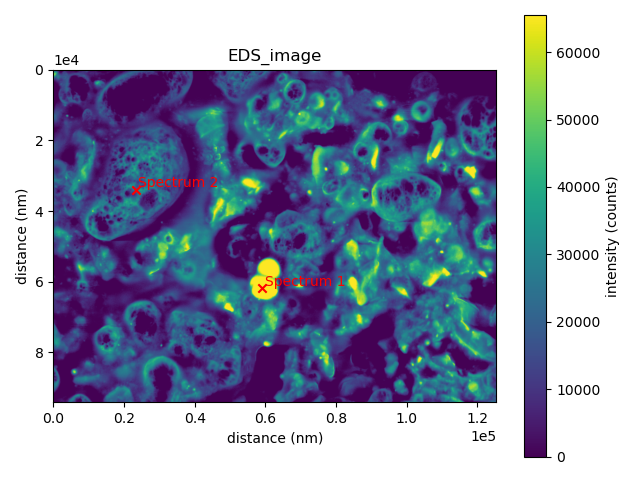

In [1]:
%matplotlib widget
import SciFiReaders
import matplotlib.pylab as plt
fname = '../example_data/EDS.rto'
reader = SciFiReaders.BrukerReader(fname)
datasets = reader.read()
image =  datasets['Channel_000']
v = image.plot()

for key, overlay in image.metadata['annotations'].items():
    plt.gca().scatter ([overlay['pos_x']*image.x.slope], [overlay['pos_y']*image.y.slope], marker="x", color='r')
    plt.gca().text((overlay['pos_x']+5)*image.x.slope, (overlay['pos_y']-5)*image.y.slope, key, color='r')

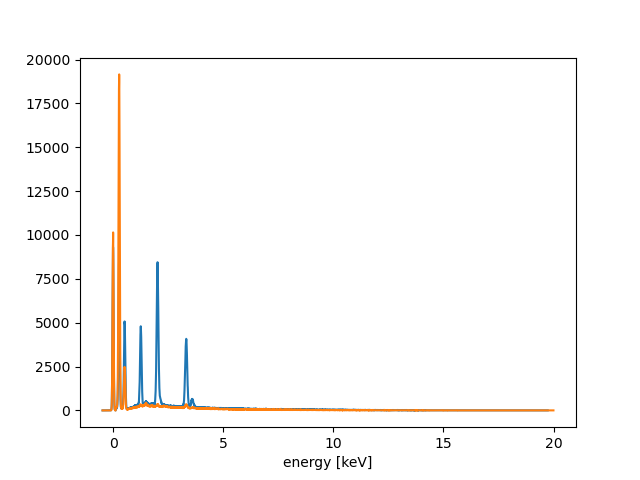

In [7]:
spectrum1 = datasets['Channel_001']
spectrum2 = datasets['Channel_002']

plt.figure()
plt.plot(spectrum1.energy_scale.values/1000, spectrum1, label='spectrum 1')
plt.plot(spectrum2.energy_scale.values/1000, spectrum2, label='spectrum 2')
plt.gca().set_xlabel('energy [keV]');


In [3]:
def get_spectrum(tags, key=0):
    spectrum = tags['spectrum'][key]
    offset = float(spectrum['spectrum_header']['CalibAbs'])
    scale  = float(spectrum['spectrum_header']['CalibLin'])
    energy_scale = np.arange(len(spectrum))*scale+offset
    dataset = sidpy.Dataset.from_array(spectrum['data'])
    energy_scale = (np.arange(len(dataset))*scale+offset)*1000
    dataset.units = 'counts'
    dataset.quantity = 'intensity'
    dataset.data_type = 'spectrum'
    
    dataset.modality = 'EDS'
    dataset.title = 'spectrum'
    dataset.set_dimension(0, sidpy.Dimension(energy_scale,
                                             name='energy_scale', units='eV',
                                             quantity='energy',
                                             dimension_type='spectral'))

    dataset.metadata['experiment'] = tags['esma']
    dataset.metadata['EDS'] = {'detector': tags['detector']} 
    dataset.metadata['EDS']['results'] = {}
    for key, result in spectrum['results'].items():
        if 'Name' in result:
            key = result['Name']
            dataset.metadata['EDS']['results'][result['Name']] = result
    
    return dataset

In [4]:
offset = float(tags['spectrum'][0]['spectrum_header']['CalibAbs'])
scale  = float(tags['spectrum'][0]['spectrum_header']['CalibLin'])
energy_scale1 = np.arange(len(spectrum1))*scale+offset
offset = float(tags['spectrum'][1]['spectrum_header']['CalibAbs'])
scale  = float(tags['spectrum'][1]['spectrum_header']['CalibLin'])
energy_scale2 = np.arange(len(spectrum2))*scale+offset
plt.figure()
plt.plot(energy_scale1,spectrum1, label = 'spectrum 1')
plt.plot(energy_scale2,spectrum2, label = 'spectrum 2')
plt.gca().set_xlabel('energy [keV]');



NameError: name 'tags' is not defined

NameError: name 'tags' is not defined

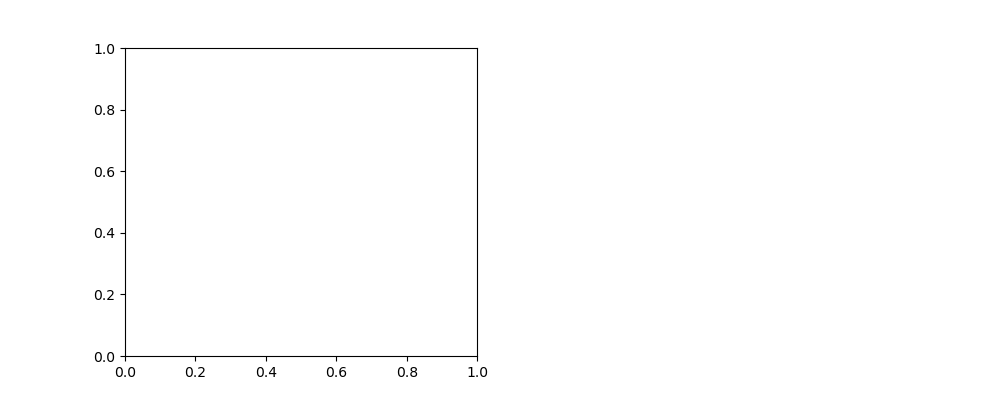

In [8]:
plt.figure(figsize=(10,4))

ax1 = plt.subplot(1,2,1)
ax1.imshow(tags['image'][0]['data']['0'])
for key in tags['overlay']['image1']:
    d = tags['overlay']['image1'][key]
    ax1.scatter ([d['posX']], [d['posY']], marker="x", color='r')
    ax1.text(d['posX']+5, d['posY']-5, key, color='r')

ax2 = plt.subplot(1,2,2)    
plt.plot(energy_scale1,spectrum1, label = 'spectrum 1')
plt.plot(energy_scale2,spectrum2, label = 'spectrum 2')
plt.gca().set_xlabel('energy [keV]')
plt.xlim(0,5)
plt.ylim(0)
plt.tight_layout()
plt.legend();


In [5]:
print(tags['spectrum'][1]['results']['6'])

NameError: name 'tags' is not defined

In [18]:
tags['image'][0].keys()

dict_keys(['width', 'height', 'dtype', 'scale_x', 'scale_y', 'plane_count', 'date', 'time', 'data'])

## Find Maximas

Of course we can find the maxima with the first derivative

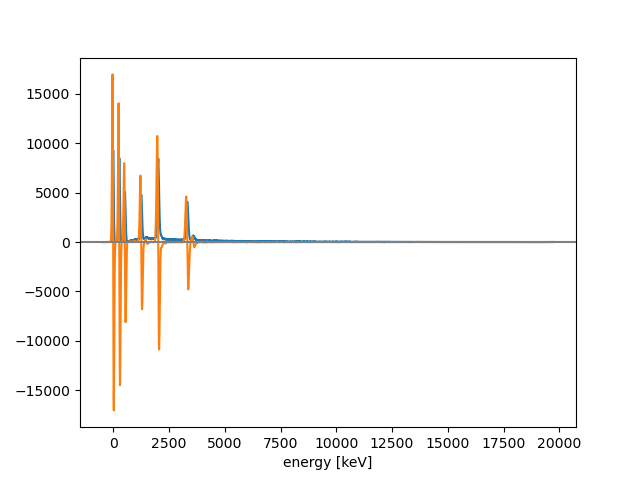

In [17]:
from scipy.interpolate import InterpolatedUnivariateSpline

# Get a function that evaluates the linear spline at any x
f = InterpolatedUnivariateSpline(spectrum1.energy_scale.values,spectrum1, k=1)

# Get a function that evaluates the derivative of the linear spline at any x
dfdx = f.derivative()

# Evaluate the derivative dydx at each x location...
dydx = dfdx(spectrum1.energy_scale.values)
from scipy.ndimage import gaussian_filter


plt.figure()
plt.plot(spectrum1.energy_scale.values,spectrum1, label = 'spectrum 1')

#plt.plot(energy_scale1, dydx)
plt.plot(spectrum1.energy_scale.values,gaussian_filter(dydx, sigma=3)*100)
plt.gca().axhline(y=0,color='gray')
plt.gca().set_xlabel('energy [keV]');

## Peak Finding

We can also use the peak finding routine of the [scipy.signal](https://docs.scipy.org/doc/scipy/reference/signal.html) to find all the maxima.


2


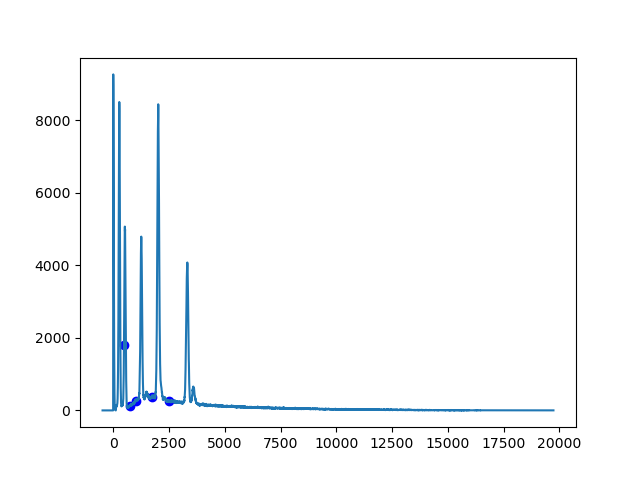

In [32]:
# -------- Input ---------
minimum_number_of_peaks=5
# -------------------------
prominence=10
import scipy
import numpy as np
spectrum = spectrum1
energy_scale1 = spectrum1.energy_scale.values
energy_scale = energy_scale1*1000
resolution = 120
start = np.searchsorted(energy_scale, 120)
spectrum[:start] = 0
## we use half the width of the resolution for smearing
width = int(np.ceil(resolution/(energy_scale[1]-energy_scale[0])/2)+1)
print(width)
new_spectrum =  spectrum#scipy.signal.savgol_filter(np.array(spectrum)[start:], width, 2)

minor_peaks, _  = scipy.signal.find_peaks(new_spectrum, prominence=prominence)

while len(minor_peaks) > minimum_number_of_peaks:
    prominence+=10
    minor_peaks, _  = scipy.signal.find_peaks(new_spectrum, prominence=prominence)
minor_peaks = np.array(minor_peaks)+start


plt.figure()
plt.plot(spectrum.energy_scale.values, spectrum, label = 'spectrum')
#plt.plot(spectrum.energy_scale.values[start:], new_spectrum, label = 'filtered spectrum 1')
plt.scatter(spectrum.energy_scale.values[minor_peaks], spectrum[minor_peaks], color = 'blue')


### Peak identification

Here we look up all the elements and see whether the position of major line (K-L3, K-L2' or 'L3-M5') coincides with a peak position as found above.

Then we plot all the lines of such an element with the appropriate weight.

To reduce confusing elements, we apply the following scheme:
- We start with the tallest peak and determine the element.
- We mark those peaks as recognized
- We move on to the next tallest peaks in the remainding peak list

The positions and the weight are tabulated in the **cross-section** dictionary file of pyTEMlib introduced in the [Characteristic X-Ray peaks](CH4-Characteristic_X_Rays.ipynb#X-ray-Weight-of-Lines) notebook

In [14]:
energy_scale = spectrum.get_spectral_dims(return_axis=True)[0].values
element_list = set()
peaks = minor_peaks[np.argsort(spectrum[minor_peaks])]
accounted_peaks = set()
for i, peak in reversed(list(enumerate(peaks))):
    for z in range(5, 82):
        if i in accounted_peaks:
            continue
        edge_info  = pyTEMlib.eels_tools.get_x_sections(z)
        # element = edge_info['name']
        lines = edge_info.get('lines', {})
        if abs(lines.get('K-L3', {}).get('position', 0) - energy_scale[peak]) <40:
            element_list.add(edge_info['name'])
            for key, line in lines.items():
                dist = np.abs(energy_scale[peaks]-line.get('position', 0))
                if key[0] == 'K' and np.min(dist)< 40:
                    ind = np.argmin(dist)
                    accounted_peaks.add(ind)
        # This is a special case for boron and carbon
        elif abs(lines.get('K-L2', {}).get('position', 0) - energy_scale[peak]) <30:
            accounted_peaks.add(i)
            element_list.add(edge_info['name'])

        if abs(lines.get('L3-M5', {}).get('position', 0) - energy_scale[peak]) <50:
            element_list.add(edge_info['name'])
            for key, line in edge_info['lines'].items():
                dist = np.abs(energy_scale[peaks]-line.get('position', 0))
                if key[0] == 'L' and np.min(dist)< 40 and line['weight'] > 0.01:
                    ind = np.argmin(dist)
                    accounted_peaks.add(ind)
list(element_list)


C:\Users\gduscher\AppData\Local\anaconda3\Lib\site-packages\dask\array\core.py:1738: FutureWarning: The `numpy.argsort` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(


['O', 'P', 'C', 'K', 'Mg']

Using energy resolution of 138 eV


['O', 'P', 'C', 'K', 'Mg']

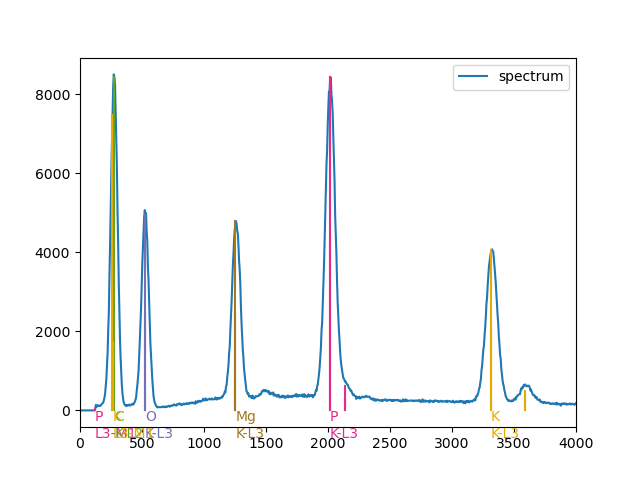

In [15]:
# --------Input -----------
minimum_number_of_peaks = 5
# --------------------------

elements = pyTEMlib.eds_tools.get_elements(spectrum, minimum_number_of_peaks, verbose=False)

plt.figure()
plt.plot(spectrum.energy_scale, spectrum, label = 'spectrum')

pyTEMlib.eds_tools.plot_lines(spectrum.metadata['EDS'], plt.gca())
plt.xlim(0, 4000)
plt.legend();
elements
    

## Plotting Gaussians in the Peaks

Please note the different width (FWHM). Here I guessed the peak width for two peaks.

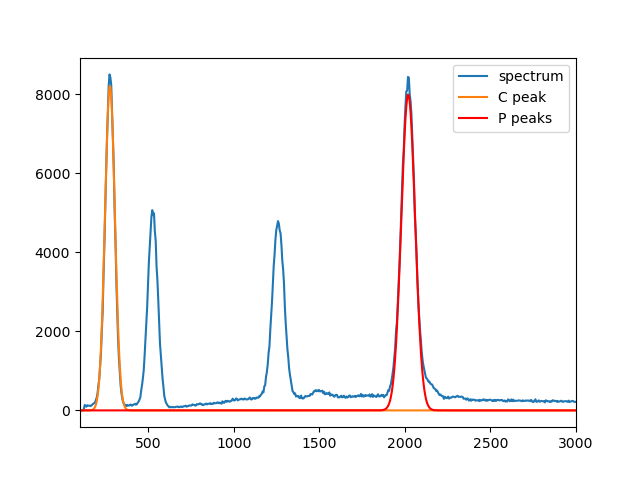

In [16]:
def gaussian(energy_scale: np.ndarray, mu: float, fwhm: float) -> np.ndarray:
    """ Gaussian function"""
    sig = fwhm/2/np.sqrt(2*np.log(2))
    return np.exp(-np.power(np.array(energy_scale) - mu, 2.) / (2 * np.power(sig, 2.)))
    
energy_scale = spectrum.energy_scale
C_peak = gaussian(spectrum.energy_scale, 275, 68)
P_peak = gaussian(spectrum.energy_scale, 2019, 95)
plt.figure()

plt.plot(energy_scale, spectrum, label = 'spectrum')
plt.plot(energy_scale,C_peak*8233, label = 'C peak')
plt.plot(energy_scale,P_peak*8000, label = 'P peaks', color = 'red')
plt.xlim(100,3000)
plt.legend()

## Origin of Line Width

Electron hole pairs are created with a standard deviation corresponding to the quantum mechanical shot-noise (Poisson statistic).
The distribution is then a Gaussian with the width of the standard deviation $\sigma$.

For the Mn K-L2,3 peak< this width would be 40 electron hole pairs.
The full width at half maximum (FWHM) of the Mn K-L2,3 edge would then be (FWHM of Gaussian  is 2.35 * 𝜎) about 106 eV a major component of the observed 125 eV in good EDS systems.


##  Line Width Estimate
Fiori and Newbury 1978
From a reference peak at $E_{ref}$  and the measured FWHM of the peak $FWHM_{ref}$ in eV, we can estimate the peak width of the other peaks

$$ FWHM =  \sqrt{2.5 \times (E-E_{ref}) + FWHM_{ref}^2 }$$ 

Gernerally we use the Mn K-L2,3 peak $E_{ref}$ = 5895 eV as a reference. In our spectrometer we got for the setup above: $FWHM_{ref} = 136$ eV

In [19]:
E_ref = 5895.0 # eV
FWHM_ref = 136 # eV
E= 275   # eV = Carbon
def get_fwhm(energy: float, energy_ref: float, fwhm_ref: float) -> float:
    """ Calculate FWHM of Gaussians"""
    return np.sqrt(2.5*(energy-energy_ref)+fwhm_ref**2)
print(get_fwhm(E, E_ref,  FWHM_ref))

66.6783323126786


Using that we get for all peaks in the low energy region:

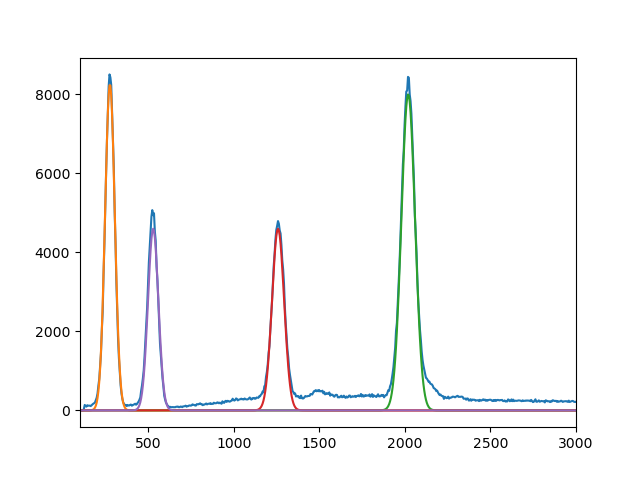

In [20]:
def get_peak(energy: float, energy_scale: np.ndarray,
             energy_ref: float = 5895.0, fwhm_ref: float = 136) -> np.ndarray:
    """ Generate a normalized Gaussian peak for a given energy."""
    # all energies in eV
    fwhm  = get_fwhm(energy, energy_ref, fwhm_ref)
    gauss = gaussian(energy_scale, energy, fwhm)

    return gauss /(gauss.max()+1e-12)
    
E= 275 
C_peak = get_peak(E,energy_scale)
E = 2019
P_peak = get_peak(E,energy_scale)
E = 1258
Al_peak = get_peak(E,energy_scale)
E = 528
O_peak = get_peak(E,energy_scale)
plt.figure()

plt.plot(energy_scale,spectrum, label = 'filtered spectrum 1')
plt.plot(energy_scale,C_peak*8233, label = 'filtered spectrum 1')
plt.plot(energy_scale,P_peak*8000, label = 'filtered spectrum 1')
plt.plot(energy_scale,Al_peak*4600, label = 'filtered spectrum 1')
plt.plot(energy_scale,O_peak*4600, label = 'filtered spectrum 1')
plt.xlim(100,3000)

peaks = [C_peak, P_peak, Al_peak, O_peak]
p = [8233, 8000, 4600, 4600 ]

## Detector Efficiency

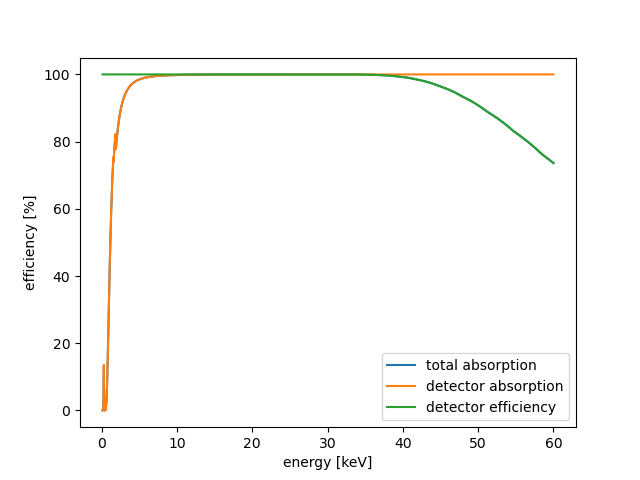

In [21]:
from scipy.interpolate import interp1d
import scipy.constants as const


## layer thicknesses of commen materials in EDS detectors in m
nickelLayer = 0.* 1e-9 # in m
alLayer = 30 *1e-9    # in m
C_window = 2 *1e-6    # in m
goldLayer = 0.* 1e-9   # in m
deadLayer = 100 *1e-9  # in m
detector_thickness = 45 * 1e-3  # in m

area = 30 * 1e-6 #in m2
oo4pi = 1.0 / (4.0 * np.pi)

#We make a linear energy scale 
energy_scale = np.linspace(.1,60,2000)

from pyTEMlib.xrpa_x_sections import x_sections
ffast = x_sections
#photoabsorption = x_sections[str(Z)]['dat']/1e10/x_sections[str(Z)]['photoabs_to_sigma']
## interpolate mass absorption coefficient to our energy scale
lin = interp1d(ffast['14']['ene']/1000.,ffast['14']['dat']/1e10/x_sections['14']['photoabs_to_sigma'],kind='linear') 
mu_Si = lin(energy_scale) * ffast['14']['nominal_density']*100. #1/cm -> 1/m

## interpolate mass absorption coefficient to our energy scale
lin = interp1d(ffast['13']['ene']/1000.,ffast['13']['dat']/1e10/x_sections['13']['photoabs_to_sigma'],kind='linear') 
mu_Al = lin(energy_scale) * ffast['13']['nominal_density'] *100. #1/cm -> 1/m

lin = interp1d(ffast['6']['ene']/1000.,ffast['6']['dat']/1e10/x_sections['6']['photoabs_to_sigma'],kind='linear') 
mu_C = lin(energy_scale) * ffast['6']['nominal_density'] *100. #1/cm -> 1/m
 
detector_Efficiency1 = np.exp(-mu_C * C_window) * np.exp(-mu_Al * alLayer)* np.exp(-mu_Si * deadLayer) 
detector_Efficiency2 = (1.0 - np.exp(-mu_Si * detector_thickness))# * oo4pi;
detector_Efficiency =detector_Efficiency1 * detector_Efficiency2#* oo4pi;

plt.figure()
plt.plot(energy_scale, detector_Efficiency*100, label = 'total absorption')
plt.plot(energy_scale, detector_Efficiency1*100, label = 'detector absorption')
plt.plot(energy_scale, detector_Efficiency2*100, label= 'detector efficiency')
plt.gca().set_xlabel('energy [keV]');
plt.gca().set_ylabel('efficiency [%]') 
plt.legend();


## Detector Parameters from file

In [22]:
print(tags['detector']['window'])
print(tags['detector'].keys())
print(f"{float(tags['detector']['SiDeadLayerThickness'])*1e-6:.3g}")
print(f"{float(tags['detector']['DetectorThickness'])/10:.3f}")
for key in tags['detector']['window']:
    print(f"{tags['detector']['window'][key]['Z']}, {tags['detector']['window'][key]['thickness']*1e-6:.2g}")

{'Layer0': {'Z': '5', 'thickness': 1.3e-07}, 'Layer1': {'Z': '6', 'thickness': 1.45e-06}, 'Layer2': {'Z': '7', 'thickness': 4.5000000000000003e-07}, 'Layer3': {'Z': '8', 'thickness': 8.500000000000001e-07}, 'Layer4': {'Z': '13', 'thickness': 3.5000000000000004e-07}, 'Layer5': {'Z': '14', 'thickness': 0.0038000000000000004, 'relative_area': 0.23}}
dict_keys(['TRTKnownHeader', 'Technology', 'Serial', 'Type', 'DetectorThickness', 'SiDeadLayerThickness', 'DetLayers', 'WindowType', 'window', 'CorrectionType', 'ResponseFunctionCount', 'SampleCount', 'SampleOffset', 'PulsePairResTimeCount', 'PileUpMinEnergy', 'PileUpWithBG', 'TailFactor', 'ShelfFactor', 'ShiftFactor', 'ShiftFactor2', 'ShiftData', 'PPRTData', 'energy_resolution', 'start_channel'])
2.9e-14
0.005
5, 1.3e-13
6, 1.5e-12
7, 4.5e-13
8, 8.5e-13
13, 3.5e-13
14, 3.8e-09


0.045


C:\Users\gduscher\AppData\Local\Temp\ipykernel_10184\2222177786.py:70: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(energy_scale*1000, detector_Efficiency , label = 'generic')


array([1.        , 1.        , 1.        , ..., 0.9998767 , 0.99987681,
       0.99987692], shape=(4043,))

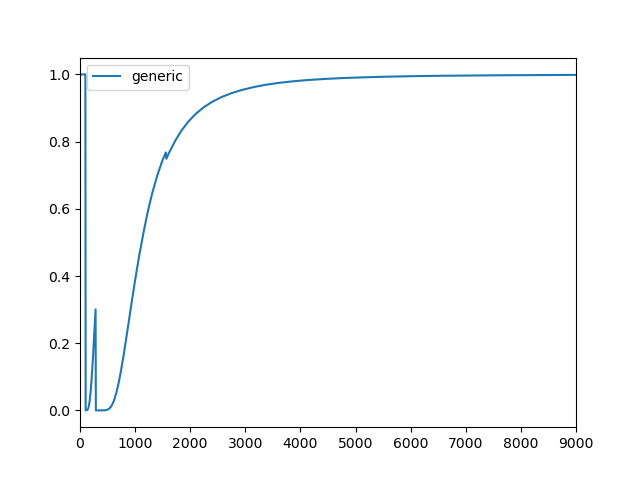

In [23]:
from scipy.interpolate import interp1d
import scipy.constants as const

def detector_efficiency(tags, energy_scale2):
    detector_Efficiency1 = np.ones(len(energy_scale2))
    for key in tags['detector']['window']:
        Z = int(tags['detector']['window'][key]['Z'])
        if Z < 14:
            t = tags['detector']['window'][key]['thickness']

            ## interpolate mass absorption coefficient to our energy scale
            lin = interp1d(x_sections[str(Z)]['ene']/1000.,x_sections[str(Z)]['dat']/1e10/x_sections[str(Z)]['photoabs_to_sigma'],kind='linear') 
            mu = lin(energy_scale2) * ffast[Z]['nominal_density']*100. #1/cm -> 1/m
            detector_Efficiency1 = detector_Efficiency1 * np.exp(-mu * t)
            print(Z,t)
        
    t = float(tags['detector']['SiDeadLayerThickness'])*1e-6
    print(t)
    t = .30*1e-7
    
    lin = interp1d(ffast[14]['E'],ffast[14]['photoabsorption'],kind='linear') 
    mu = lin(energy_scale) * ffast[14]['nominal_density']*100. #1/cm -> 1/m
    detector_Efficiency1 = detector_Efficiency1 * np.exp(-mu * t)
    detector_thickness = float(tags['detector']['DetectorThickness'])*1e-1
    ## interpolate mass absorption coefficient to our energy scale
    mu_Si = lin(energy_scale) * ffast[14]['nominal_density']*100. #1/cm -> 1/m
    print(detector_thickness)
    
    detector_Efficiency2 = (1.0 - np.exp(-mu * detector_thickness))# * oo4pi;

    
    return detector_Efficiency1*detector_Efficiency2

energy_scale =spectrum.energy_scale
start = np.searchsorted(spectrum.energy_scale, 100)
energy_scale =spectrum.energy_scale[start:]
# de = detector_efficiency(tags, energy_scale)    
## layer thicknesses of commen materials in EDS detectors in m
nickelLayer = 0.* 1e-9 # in m
alLayer = 30 *1e-9    # in m
C_window = 2 *1e-6    # in m
goldLayer = 0.* 1e-9   # in m
deadLayer = 100 *1e-9  # in m
detector_thickness = 45 * 1e-3  # in m
print(detector_thickness)
area = 30 * 1e-6 #in m2
oo4pi = 1.0 / (4.0 * np.pi)

#We make a linear energy scale 

## interpolate mass absorption coefficient to our energy scale
lin = interp1d(ffast['14']['ene'],ffast['14']['dat']/1e10/x_sections['14']['photoabs_to_sigma'],kind='linear') 
mu_Si = lin(energy_scale) * ffast['14']['nominal_density']*100. #1/cm -> 1/m

## interpolate mass absorption coefficient to our energy scale
lin = interp1d(ffast['13']['ene'],ffast['13']['dat']/1e10/x_sections['13']['photoabs_to_sigma'],kind='linear') 
mu_Al = lin(energy_scale) * ffast['13']['nominal_density'] *100. #1/cm -> 1/m

lin = interp1d(ffast['6']['ene'],ffast['6']['dat']/1e10/x_sections['6']['photoabs_to_sigma'],kind='linear') 
mu_C = lin(energy_scale) * ffast['6']['nominal_density'] *100. #1/cm -> 1/m
 
 
detector_Efficiency1 = np.exp(-mu_C * C_window) * np.exp(-mu_Al * alLayer)#* np.exp(-mu_Si * deadLayer) 
detector_Efficiency2 = (1.0 - np.exp(-mu_Si * detector_thickness))# * oo4pi;
energy_scale =spectrum.energy_scale
detector_Efficiency = np.ones(len(energy_scale))
detector_Efficiency[start:] =detector_Efficiency1 * detector_Efficiency2#* oo4pi;

plt.figure()
plt.plot(energy_scale*1000, detector_Efficiency , label = 'generic')
#plt.plot(energy_scale[start:]*1000, detector_Efficiency, label = 'UTK detector')
#plt.plot(energy_scale*1000, de* np.exp(-mu_Si * deadLayer) )
#plt.plot(energy_scale*1000, de* np.exp(-mu_Si * deadLayer) * detector_Efficiency2 )
plt.legend();
plt.xlim(0,9000);

energy_scale =spectrum.energy_scale
detector_Efficiency

## Comparison to generic efficiency

## Plotting background and lines 

In [24]:
out_tags = {}
x_sections = pyTEMlib.xrpa_x_sections.x_sections
energy_scale = spectrum.get_spectral_dims(return_axis=True)[0].values
for element in element_list:
    atomic_number = pyTEMlib.utilities.get_z(element)
    out_tags[element] ={'Z': atomic_number}
    lines = pyTEMlib.xrpa_x_sections.x_sections.get(str(atomic_number), {}).get('lines', {})
    if not lines:
        break
    line_dict = {'K': {'lines': [],
                       'main': None,
                       'weight': 0}, 
                 'L': {'lines': [],
                       'main': None,
                       'weight': 0}, 
                 'M': {'lines': [],
                       'main': None,
                       'weight': 0}}

    for key, line in lines.items():
        if key[0] in line_dict:
            if line['position'] < energy_scale[-1]:
                line_dict[key[0]]['lines'].append(key)
                if line['weight'] > line_dict[key[0]]['weight']:
                    line_dict[key[0]]['weight'] = line['weight']
                    line_dict[key[0]]['main'] = key

    for key, family in line_dict.items():
        if family['weight'] > 0:
            out_tags[element].setdefault(f'{key}-family', {}).update(family)
            position = x_sections[str(atomic_number)]['lines'][family['main']]['position']
            height = spectrum[np.searchsorted(energy_scale, position)].compute()
            out_tags[element][f'{key}-family']['height'] = height/family['weight']
            z = str(atomic_number)
            for key in family['lines']:
                out_tags[element][f'{key[0]}-family'][key] = x_sections[z]['lines'][key]
    spectrum.metadata.setdefault('EDS', {}).update(out_tags)



peaks = [C_peak, P_peak, Al_peak, O_peak]
pp = [4233, 8000, 4600, 4600 ]
pp.extend([0, 1,  0.026, 0.003])
fit_parameter = p
out_tags.keys()

dict_keys(['O', 'P', 'C', 'K', 'Mg'])

In [25]:
p

[8233, 8000, 4600, 4600]

## As a function

np.int64(116)

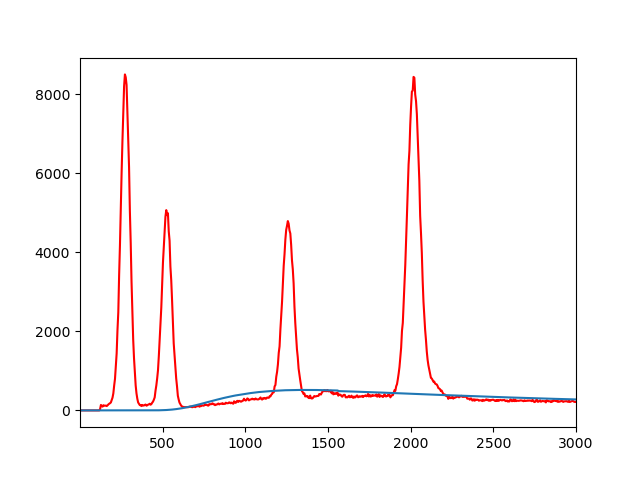

In [26]:

def model(p9,energy_scale):
    e_0 = 20000
    
    model = np.zeros(len(energy_scale))
    model[start:] = bremsstrahlung = (pp[-3] + pp[-2] * (e_0 - energy_scale[start:]) / energy_scale[start:] +
                          pp[-1] * (e_0 - energy_scale[start:])**2 / energy_scale[start:])
    
    model *= detector_Efficiency
    model[:start+40] =0
    
    for i in range(len(p9)-4):
        model = model+ peaks[i]*abs(p9[i])
        pass
    return model
spectrum3 = model(fit_parameter,energy_scale)
plt.figure()

plt.plot(energy_scale, spectrum, label = 'filtered spectrum 1',color='red')
plt.plot(energy_scale, spectrum3)
plt.xlim(1, 3000)
start

## Fitting above function to spectrum

In [27]:
plt.close('all')

In [28]:

from scipy.optimize import leastsq 

## background fitting 
def specfit(p, y, x):
    err = y - model(p,x)
    return err

p_fitted, lsq = leastsq(specfit, p, args=(spectrum, energy_scale), maxfev=2000)
np.round(p_fitted, 4), p

(array([8233., 8000., 4600., 4600.]), [8233, 8000, 4600, 4600])

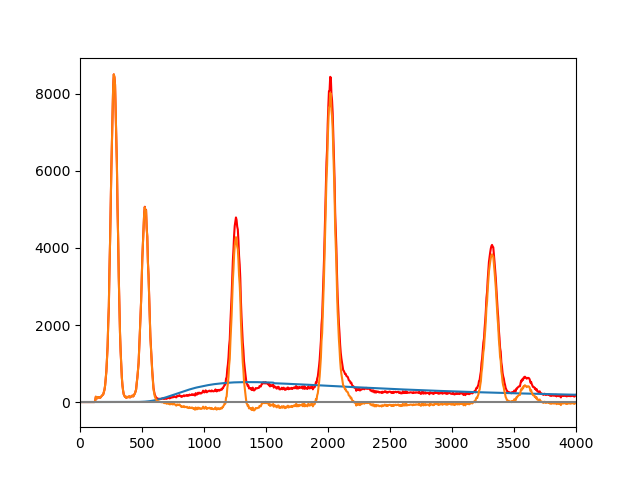

In [29]:
spectrum3 = model(p_fitted, energy_scale)

plt.figure()

plt.plot(energy_scale, spectrum, label = 'filtered spectrum 1',color='red')
plt.plot(energy_scale, spectrum3)
plt.plot(energy_scale, spectrum-spectrum3)
plt.gca().axhline(y=0,color='gray');

plt.xlim(0,4000);

## Energy Scale

What happened?


## Detector Artifacts

### Si Escape peak
The 1s state of a Si atom in the detector crystal is excited but then instead of being further detected by absoption a A!!uger electron leaves the crystal. The electron hole pairs of this event are missing and a lower energy is recorded. 

![Si-Escape](./images/escape-peak2.jpg)

### Detector Silicon Peak
Internal fluorescence peak

![Si-Detector](./images/DetectorSilicon4.jpg)

### Sum Peak
Two photons are detected at the same time.
This signal is suppressed by most acquistion systems, but a few are still slipping through.
A peak apears at the energy of the sum of two strong peaks.

## Composition
Following 

[D.E. Newbury, C.R. Swyt, and R.L. Myklebust,
“Standardless” Quantitative Electron Probe
Microanalysis with Energy-Dispersive X-ray
Spectrometry: Is It Worth the Risk?, Anal. Chem. 1995, 67, 1866-1871](https://doi-org.proxy.lib.utk.edu/10.1021/ac00107a017)

to calculate the mass concentration $C_i$ from the intensity of a line ($I_{ch}$), we use:

$$ I_{ch} = \epsilon  (\omega N_A \rho C_i / A) R \int _{E_c}^{E_0} \frac{Q_i}{dE/ds}dE $$


- $\omega$ : fluorescence yield    
- $N_A$: Avogadro’s number          
- $\rho$: density                       
- $C_i$: mass concentration of element $i$  
- $A$:atomic weight           
- $R$: backscatter loss
- $Q_i$: ionization cross sectiond
- $E/ds$: rate of energy loss 
- $E_0$: incident beam energy  
- $E_c$: excitation energy
- $\epsilon$: EDS efficiency

where: $N_A * \rho * C_i/A$: volume density of element $i$ (atoms per unit volume)  

What do we know at this point?

$\omega; N_A; \rho; A; Q_i; E_0; E_c; and \epsilon$

In [252]:
def BrowningEmpiricalCrossSection(elm , energy):
    """ * Computes the elastic scattering cross section for electrons of energy between
     * 0.1 and 30 keV for the specified element target. The algorithm comes from<br>
     * Browning R, Li TZ, Chui B, Ye J, Pease FW, Czyzewski Z &amp; Joy D; J Appl
     * Phys 76 (4) 15-Aug-1994 2016-2022

     * The implementation is designed to be similar to the implementation found in
     * MONSEL.
     * Copyright: Pursuant to title 17 Section 105 of the United States Code this
     * software is not subject to copyright protection and is in the public domain
     * Company: National Institute of Standards and Technology
     * @author Nicholas W. M. Ritchie
     * @version 1.0

     */
     Modified by Gerd Duscher, UTK
    """

    #/**
    #* totalCrossSection - Computes the total cross section for an electron of
    #* the specified energy.
    #* 
    # @param energy double - In keV
    # @return double - in square meters
    #*/
    e = energy  #in keV
    re = np.sqrt(e);
    return (3.0e-22 * elm**1.7) / (e + (0.005 * elm**1.7 * re) + ((0.0007 * elm**2) / re));
   

In [253]:
print(BrowningEmpiricalCrossSection(6,277)*1e18, r'nm^2')

2.2633981858464282e-05 nm^2


## Navigation

- <font size = "3">  **Back: [Detector Response](CH4_15-Detector.ipynb)** </font>
- <font size = "3">  **Next: [Detector Response](CH4_17-Quantify_EDS.ipynb)** </font>
- <font size = "3">  **Chapter 4: [Spectroscopy](CH4_00-Spectroscopy.ipynb)** </font>
- <font size = "3">  **List of Content: [Front](../_MSE672_Intro_TEM.ipynb)** </font>
